# 52 - Why Zero Initialization Fails

**Section:** Weight Initialization | **Prereqs:** `Weight Initialization/WeightMatrixSizeExplanation.ipynb` | **Next:** `Weight Initialization/CodeChallenge_IndenticallyRandomWeights.ipynb`

Set every weight to zero and the network never learns. The reason is worth
understanding precisely, because it explains why initialisation is a topic at all.

**The symmetry argument.** If two units in a layer have identical incoming
weights, they compute identical outputs, receive identical gradients, and get
identical updates. They stay identical forever. A layer of 64 identical units has
the expressive power of one unit. With all weights zero the whole network
collapses this way and, with ReLU, most of it outputs zero regardless.

**Randomness is what breaks the symmetry** - that is its entire job. Not to be
'a good guess', just to make the units different from each other.

**Biases are the exception:** they can safely start at zero (and PyTorch nearly
does), because the *weights* already differ, so the units are not symmetric. The
second experiment here sets weights to 0 and biases to 1, which does not help -
identical biases cannot break a symmetry that identical weights created.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [2]:
# 784-64-64-64-32-10. Note the nested one-liner in forward - the same chain
# written compactly, applying fc1, fc2, fc3 in order.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784,64)

    self.fc1 = nn.Linear(64,64)

    self.fc2 = nn.Linear(64,64)

    self.fc3 = nn.Linear(64,32)

    self.output_layer = nn.Linear(32,10)

  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc3(F.relu(self.fc2(F.relu(self.fc1(x))))))

    return self.output_layer(x)

In [3]:
test = model()

In [4]:
# Zero every parameter, weights and biases alike.
# Setting all the weights and biases zero

for a,b in test.named_parameters():
  b.data = torch.zeros_like(b.data)
  print(b)

Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], requires_grad=True)
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)
Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], requires_grad=True)
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [5]:
test.fc2.weight.data

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [6]:
# Shapes as a reminder: weight (out, in), bias (out,).
test.fc2.bias.shape, test.fc2.weight.shape

(torch.Size([64]), torch.Size([64, 64]))

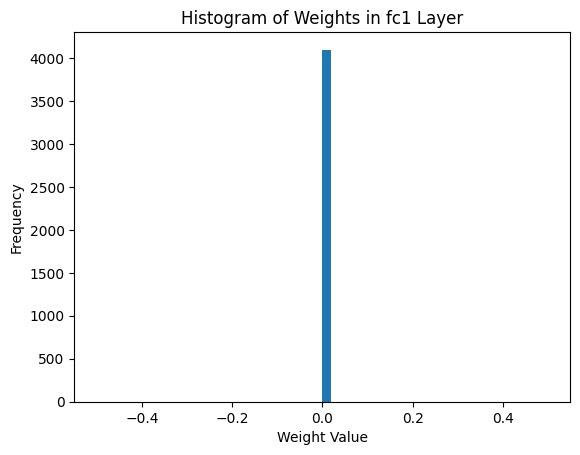

In [7]:
# The histogram: a single spike at zero. Every unit in the layer is now
# identical to every other one.
plt.hist(test.fc2.weight.data.flatten(), bins=50)
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.title('Histogram of Weights in fc1 Layer')
plt.show()

In [8]:
# Colab's small MNIST CSV.

data = np.loadtxt(open('sample_data/mnist_train_small.csv','rb'),delimiter=',')

train_label = data[:,0]
train_data  = data[:,1:]


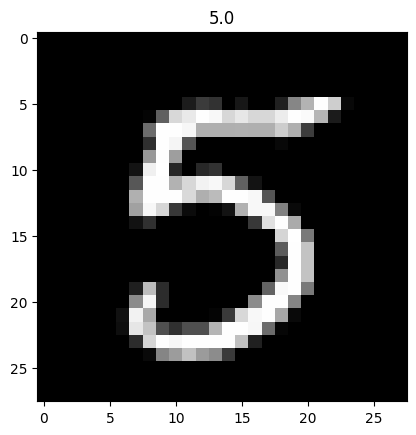

In [9]:
plt.imshow(train_data[1].reshape(28,28), cmap='gray')
plt.title(train_label[1].item());

In [10]:
# Tensors on GPU, 90/10 split, loaders.

train_label = torch.tensor(train_label, dtype=torch.long, device='cuda')
train_data = torch.tensor(train_data, dtype=torch.float, device='cuda')

train_data,test_data, train_labels,test_labels = train_test_split(train_data, train_label, test_size=.1)

trainDataSet = TensorDataset(train_data, train_labels)
testDataSet = TensorDataset(test_data, test_labels)

batchsize    = 128
train_loader = DataLoader(trainDataSet,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(testDataSet,batch_size=testDataSet.tensors[0].shape[0])

In [11]:
# One training function, two conditions: default random init, or all-zero.
# Everything else - architecture, optimizer, epochs, data - is identical, which
# is what makes the comparison clean.
def train_model(weightBool=False):

  if weightBool:
    #after
    classifier = model().to('cuda')
    for a,b in classifier.named_parameters():
     b.data = torch.zeros_like(b.data)
  else:
    classifier = model().to('cuda')

  epochs = 50
  lossFunc = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(),lr=1e-4)

  train_acc = []
  test_acc = []
  losses = []

  for epoch in range(epochs):

    batch_loss = []
    batch_acc = []

    classifier.train()

    for x,y in train_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # Train acc
      batch_acc.append(100 * torch.mean((torch.argmax(yhat,dim=1) == y).float()).cpu())

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Test on Val set
    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      preds = torch.argmax(classifier(X), dim=1)
      test_acc.append(100*torch.mean( (preds==Y).float().cpu() ))

    if epoch % 10 == 0 or epoch == epochs - 1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]}')

  return losses, train_acc, test_acc, classifier

In [12]:
# Baseline: default (random) initialisation.
losses, train_acc, test_acc, classifier  = train_model()

Epoch 0 | Loss : 1.3428737636123385
Epoch 10 | Loss : 0.09138831290017281
Epoch 20 | Loss : 0.03074528678054256
Epoch 30 | Loss : 0.00947469838179781
Epoch 40 | Loss : 0.002527685436819281
Epoch 49 | Loss : 0.0008278987550251519


In [13]:
# The zero-initialised run.
losses_zero, train_acc_zero, test_acc_zero, classifier_zero = train_model(True)

Epoch 0 | Loss : 2.302507405621665
Epoch 10 | Loss : 2.3014030643871854
Epoch 20 | Loss : 2.3009909170014518
Epoch 30 | Loss : 2.300848707130977
Epoch 40 | Loss : 2.3007935966764177
Epoch 49 | Loss : 2.3007916705948968


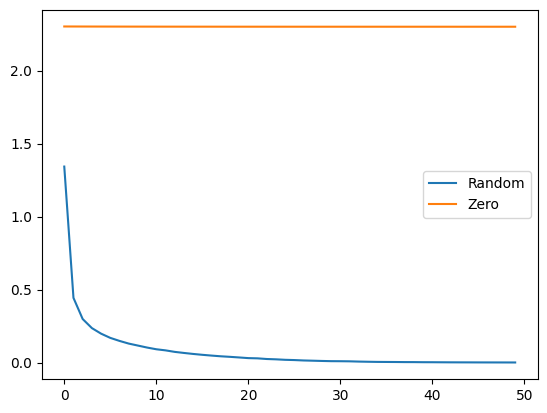

In [14]:
# Loss curves. The zero run's loss barely moves - it sits near ln(10) = 2.3,
# the loss of predicting all ten digits with equal probability.
plt.plot(losses, label="Random")
plt.plot(losses_zero, label="Zero")
plt.legend();

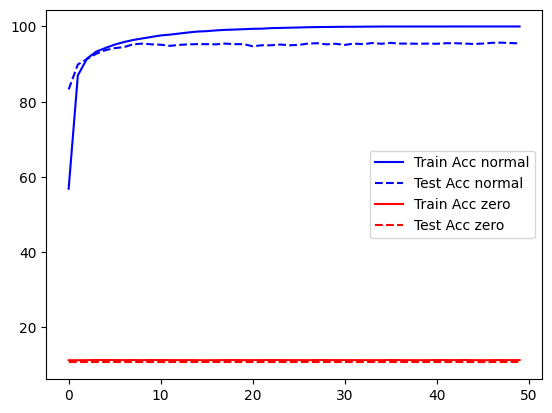

In [15]:
# Accuracy: the zero run hovers at 10%, which is chance on 10 classes. It is not
# learning slowly, it is not learning at all.
plt.plot(train_acc,'b', label = "Train Acc normal");
plt.plot(test_acc,'b--', label= "Test Acc normal")

plt.plot(train_acc_zero,'r', label = "Train Acc zero");
plt.plot(test_acc_zero,'r--', label= "Test Acc zero")
plt.legend();

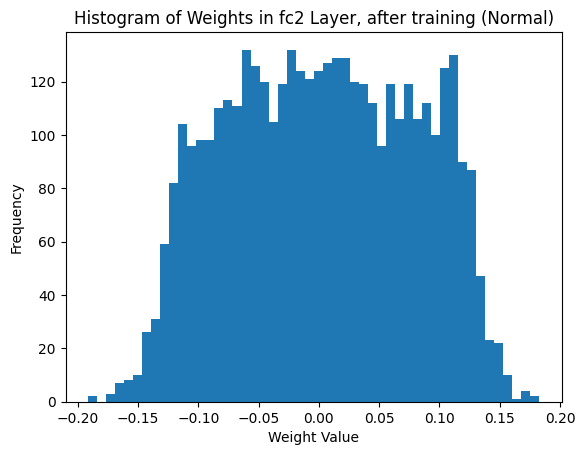

In [16]:
# Weight histogram after training from a random start - spread out, because
# different units learned different features.
plt.hist(classifier.cpu().fc2.weight.data.flatten(), bins=50)
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.title('Histogram of Weights in fc2 Layer, after training (Normal)')
plt.show()

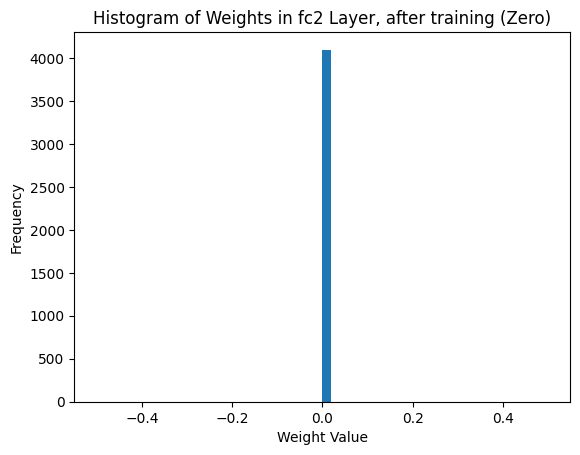

In [17]:
# Weight histogram after training from zeros. Still degenerate: symmetry was
# never broken, so the units never differentiated.
plt.hist(classifier_zero.cpu().fc2.weight.data.flatten(), bins=50)
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.title('Histogram of Weights in fc2 Layer, after training (Zero)')
plt.show()

## Now we will only set weights to 0 and biases to 1

In [18]:
# Second experiment: weights zero, biases one.
# Prediction before running it: still fails. A bias shifts a unit's output but
# is the SAME for every unit in the layer, so it cannot make two units differ.
# Only the weights can break the symmetry.
def train_model_biases(weightBool=False):

  if weightBool:
    #after
    classifier = model().to('cuda')
    for a,b in classifier.named_parameters():
      if 'weight' in a:
       b.data = torch.zeros_like(b.data)
      else:
        b.data = torch.zeros_like(b.data)+1
  else:
    classifier = model().to('cuda')

  epochs = 50
  lossFunc = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(),lr=1e-4)

  train_acc = []
  test_acc = []
  losses = []

  for epoch in range(epochs):

    batch_loss = []
    batch_acc = []

    classifier.train()

    for x,y in train_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # Train acc
      batch_acc.append(100 * torch.mean((torch.argmax(yhat,dim=1) == y).float()).cpu())

    losses.append(np.mean(batch_loss))
    train_acc.append(np.mean(batch_acc))

    # Test on Val set
    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      preds = torch.argmax(classifier(X), dim=1)
      test_acc.append(100*torch.mean( (preds==Y).float().cpu() ))

    if epoch % 10 == 0 or epoch == epochs - 1 :
      print(f'Epoch {epoch} | Loss : {losses[epoch]}')

  return losses, train_acc, test_acc, classifier

In [19]:
losses_one, train_acc_one, test_acc_one, classifier_one = train_model_biases(True)

Epoch 0 | Loss : 2.2971597058432445
Epoch 10 | Loss : 2.0309382362025126
Epoch 20 | Loss : 1.9608282268047332
Epoch 30 | Loss : 1.9218149159635816
Epoch 40 | Loss : 1.893664734704154
Epoch 49 | Loss : 1.8742647911821093


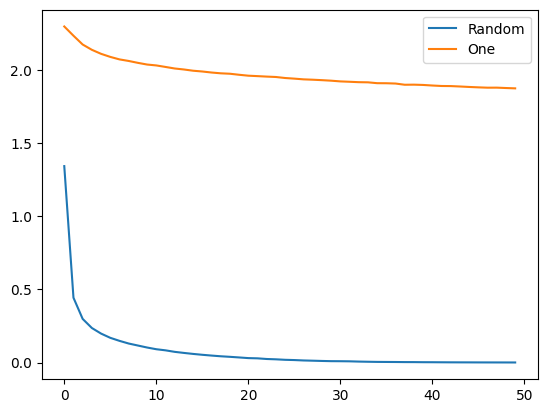

In [20]:
# Loss for the weights-zero/biases-one run, against the random baseline.
plt.plot(losses, label="Random")
plt.plot(losses_one, label="One")
plt.legend();

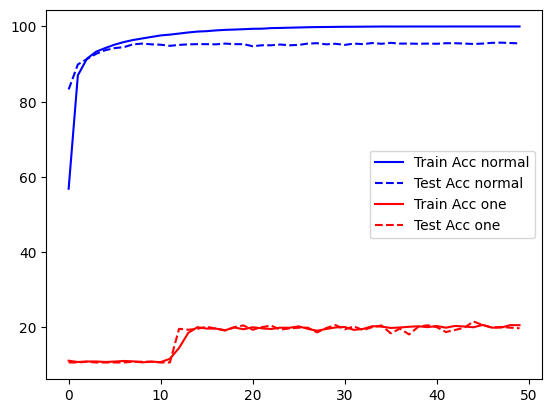

In [21]:
# Accuracy - still at chance, confirming the prediction.
plt.plot(train_acc,'b', label = "Train Acc normal");
plt.plot(test_acc,'b--', label= "Test Acc normal")

plt.plot(train_acc_one,'r', label = "Train Acc one");
plt.plot(test_acc_one,'r--', label= "Test Acc one")
plt.legend();

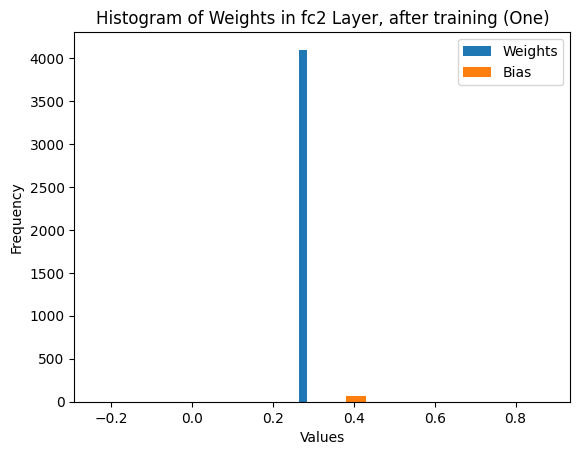

In [22]:
# Final weight and bias distributions. The biases moved (they receive non-zero
# gradients); the weights did not escape their symmetry.
plt.hist(classifier_one.cpu().fc2.weight.data.flatten(), bins=50,label = 'Weights')
plt.hist(classifier_one.cpu().fc2.bias.data.flatten(), bins=20, label = 'Bias')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of Weights in fc2 Layer, after training (One)')
plt.legend();